# OmniSearch — Comms-Dropout Sweep Results

Loads the most recent `results/comms_dropout_sweep_*.json` produced by
[`scripts/comms_dropout_sweep.py`](../scripts/comms_dropout_sweep.py) and visualises:

1. A wide pivot table of mean return per (algorithm, comms_dropout) cell
2. A line plot — mean return vs comms_dropout, one line per algorithm
3. A bar chart — wall-clock per cell (sanity check that cells took comparable time)

**Important:** the smoke run uses only 3 iters / 6,000 frames per cell. Numbers
here are below the noise floor and **should not be read as research findings**.
Re-run with `python scripts/comms_dropout_sweep.py --research` for a credible budget.

In [1]:
import sys, json, glob
from pathlib import Path
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('..') / 'results'
print(f"Results dir: {RESULTS_DIR.resolve()}")

Results dir: /Users/alexlavre/Documents/omnisearch_capstone/omnisearch/results


## 1. Load the most recent sweep

Each sweep run writes one JSON file containing a list of per-cell records.
Re-run the cell to pick up new sweeps.

In [2]:
files = sorted(RESULTS_DIR.glob('comms_dropout_sweep_*.json'))
if not files:
    raise FileNotFoundError(
        f"No sweep JSON in {RESULTS_DIR.resolve()}.\n"
        "Run: python scripts/comms_dropout_sweep.py"
    )
latest = files[-1]
print(f"Loading: {latest.name}")
rows = json.loads(latest.read_text())
df = pd.DataFrame(rows)
print(f"Cells:    {len(df)}")
print(f"Iters:    {df['iters'].unique().tolist()}")
print(f"Frames per cell: {df['frames'].unique().tolist()}")
print(f"Total wall:      {df['wall_sec'].sum():.1f} s")
df

Loading: comms_dropout_sweep_1779553897.json
Cells:    8
Iters:    [3]
Frames per cell: [6000]
Total wall:      28.8 s


,algo,comms_dropout,seed,iters,frames,mean_return,wall_sec,folder
0,mappo,0.0,0,3,6000,-1.982813,3.47,/Users/alexlavre/Documents/omnisearch_capstone...
1,mappo,0.2,0,3,6000,-0.293750,3.58,/Users/alexlavre/Documents/omnisearch_capstone...
2,mappo,0.5,0,3,6000,-0.514062,3.62,/Users/alexlavre/Documents/omnisearch_capstone...
3,mappo,0.8,0,3,6000,-0.901562,3.54,/Users/alexlavre/Documents/omnisearch_capstone...
4,ippo,0.0,0,3,6000,-2.050000,3.69,/Users/alexlavre/Documents/omnisearch_capstone...
5,ippo,0.2,0,3,6000,-1.314062,3.64,/Users/alexlavre/Documents/omnisearch_capstone...
6,ippo,0.5,0,3,6000,-1.757811,3.67,/Users/alexlavre/Documents/omnisearch_capstone...
7,ippo,0.8,0,3,6000,-0.840625,3.54,/Users/alexlavre/Documents/omnisearch_capstone...


## 2. Pivot table — mean return per (algo, dropout)

In [3]:
pivot = df.pivot_table(
    index='algo',
    columns='comms_dropout',
    values='mean_return',
    aggfunc='mean',
)
pivot.columns = [f'd={c}' for c in pivot.columns]
pivot.round(3)

,d=0.0,d=0.2,d=0.5,d=0.8
algo,,,,
ippo,-2.050,-1.314,-1.758,-0.841
mappo,-1.983,-0.294,-0.514,-0.902


## 3. Mean return vs comms_dropout

Hypothesis (untestable at smoke budget): IPPO should degrade faster than MAPPO as
comms_dropout grows, because MAPPO's centralized critic still sees the global
state while IPPO doesn't.

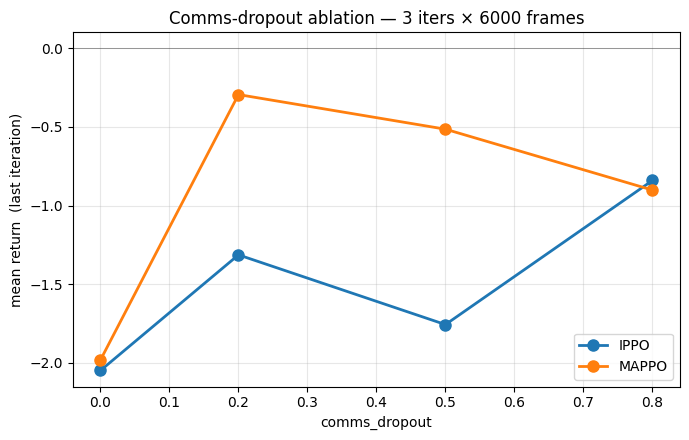

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for algo, g in df.groupby('algo'):
    g = g.sort_values('comms_dropout')
    ax.plot(g['comms_dropout'], g['mean_return'],
            marker='o', linewidth=2, markersize=8, label=algo.upper())
ax.set_xlabel('comms_dropout')
ax.set_ylabel('mean return  (last iteration)')
ax.set_title(f"Comms-dropout ablation — {df['iters'].iloc[0]} iters × {df['frames'].iloc[0]} frames")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Wall-clock per cell

Sanity check that no cell is unusually slow (which would suggest config drift).

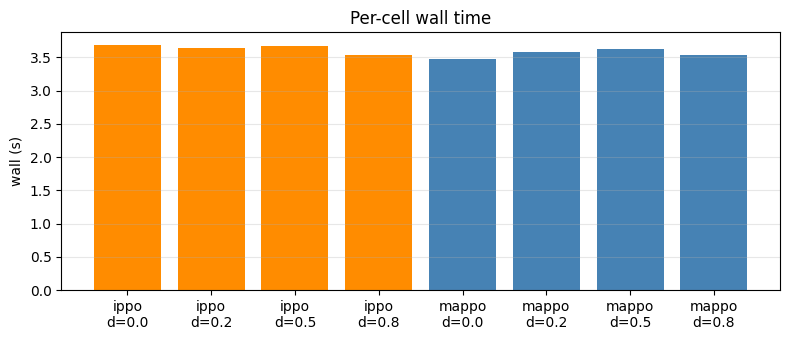

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
df_sorted = df.sort_values(['algo', 'comms_dropout'])
labels = [f"{r.algo}\nd={r.comms_dropout}" for r in df_sorted.itertuples()]
colors = ['steelblue' if a == 'mappo' else 'darkorange' for a in df_sorted['algo']]
ax.bar(labels, df_sorted['wall_sec'], color=colors)
ax.set_ylabel('wall (s)')
ax.set_title('Per-cell wall time')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## To get research-grade numbers

```bash
python scripts/comms_dropout_sweep.py --research     # ~400k frames/cell
```

For a credible paper you'd also want:
- 3–5 seeds per cell (add a seed loop in [`scripts/comms_dropout_sweep.py`](../scripts/comms_dropout_sweep.py))
- Confidence bands (mean ± stderr) on the line plot
- A second metric — survivors found, not just total reward — to disentangle reward shaping from task success